In [ ]:
from google.colab import files
files.upload()

Saving ev.csv to ev.csv


{'ev.csv': b'Station ID,Latitude,Longitude,Address,Charger Type,Cost (USD/kWh),Availability,Distance to City (km),Usage Stats (avg users/day),Station Operator,Charging Capacity (kW),Connector Types,Installation Year,Renewable Energy Source,Reviews (Rating),Parking Spots,Maintenance Frequency\r\nEVS00001,-33.400998,77.974972,"4826 Random Rd, City 98, Country",AC Level 2,0.27,9:00-18:00,4.95,35,EVgo,350,"CCS, CHAdeMO",2013,Yes,4.0,7,Annually\r\nEVS00002,37.861857,-122.490299,"8970 San Francisco Ave, San Francisco",DC Fast Charger,0.19,24/7,4.96,83,EVgo,350,"Tesla, Type 2",2010,Yes,3.9,2,Monthly\r\nEVS00003,13.776092,100.412776,"5974 Bangkok Ave, Bangkok",AC Level 2,0.48,6:00-22:00,8.54,24,ChargePoint,50,"Type 2, CCS",2019,No,3.6,9,Annually\r\nEVS00004,43.62825,-79.468935,"6995 Toronto Ave, Toronto",AC Level 1,0.41,9:00-18:00,13.28,70,Greenlots,350,Type 2,2010,Yes,4.2,7,Monthly\r\nEVS00005,19.119865,72.913368,"5704 Mumbai Ave, Mumbai",AC Level 2,0.11,9:00-18:00,9.76,19,EVgo,350,CCS,2015,Y

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("ev.csv")
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataset Info:")
df.info()
print("\nNumerical Summary:")
print(df.describe())
print("Dataset Shape:", df.shape)
print("\nColumns",df.columns.tolist())


First 5 Rows:
  Station ID   Latitude   Longitude                                Address  \
0   EVS00001 -33.400998   77.974972       4826 Random Rd, City 98, Country   
1   EVS00002  37.861857 -122.490299  8970 San Francisco Ave, San Francisco   
2   EVS00003  13.776092  100.412776              5974 Bangkok Ave, Bangkok   
3   EVS00004  43.628250  -79.468935              6995 Toronto Ave, Toronto   
4   EVS00005  19.119865   72.913368                5704 Mumbai Ave, Mumbai   

      Charger Type  Cost (USD/kWh) Availability  Distance to City (km)  \
0       AC Level 2            0.27   9:00-18:00                   4.95   
1  DC Fast Charger            0.19         24/7                   4.96   
2       AC Level 2            0.48   6:00-22:00                   8.54   
3       AC Level 1            0.41   9:00-18:00                  13.28   
4       AC Level 2            0.11   9:00-18:00                   9.76   

   Usage Stats (avg users/day) Station Operator  Charging Capacity (kW)

In [ ]:
#data cleaning
print("Duplicate rows before removing:", df.duplicated().sum())

print("\nMissing values after handling:")
# Check missing values
print(df.isnull().sum())

# Fill numeric missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical missing values
df["Availability"].fillna(df["Availability"].mode()[0], inplace=True) #finds the most frequently occurring value
df["Charger Type"].fillna(df["Charger Type"].mode()[0], inplace=True)

# Remove any remaining missing values
df.dropna(inplace=True)
print("then")
# Verify data
print(df.info())

Duplicate rows before removing: 0

Missing values after handling:
Station ID                     0
Latitude                       0
Longitude                      0
Address                        0
Charger Type                   0
Cost (USD/kWh)                 0
Availability                   0
Distance to City (km)          0
Usage Stats (avg users/day)    0
Station Operator               0
Charging Capacity (kW)         0
Connector Types                0
Installation Year              0
Renewable Energy Source        0
Reviews (Rating)               0
Parking Spots                  0
Maintenance Frequency          0
dtype: int64
then
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Station ID                   5000 non-null   object 
 1   Latitude                     5000 non-null   float64
 2   Longitude  

/tmp/ipykernel_818/1770879450.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Availability"].fillna(df["Availability"].mode()[0], inplace=True)
/tmp/ipykernel_818/1770879450.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [ ]:
import numpy as np
import pandas as pd

# -----------------------------
# STEP 8 : FEATURE ENGINEERING:creating new columns (features) from existing data
# -----------------------------

# 1. Station Utilization (%)
# Assume each station can handle 100 users/day
MAX_CAPACITY = 100

df["Station Utilization (%)"] = (
    df["Usage Stats (avg users/day)"] / MAX_CAPACITY
) * 100

# Limit utilization to 100%
df["Station Utilization (%)"] = df["Station Utilization (%)"].clip(upper=100) #limits values.><100=100


# ------------------------------------------
# 2. Distance to Nearest Station (Estimated)
# ------------------------------------------
# Since the dataset contains only one distance field,
# use Distance to City as an estimate.

df["Distance to Nearest Station (km)"] = df["Distance to City (km)"] #estimated value.


# ------------------------------------------
# 3. Demand Score (0-100)
# ------------------------------------------
# Higher users + higher charging capacity = higher demand

usage_score = (
    df["Usage Stats (avg users/day)"] /
    df["Usage Stats (avg users/day)"].max()#estimated value.
)

capacity_score = (
    df["Charging Capacity (kW)"] /
    df["Charging Capacity (kW)"].max()
)

df["Demand Score"] = ( #Higher Demand Score means higher future charging demand.
    (0.7 * usage_score) +
    (0.3 * capacity_score)
) * 100


# ------------------------------------------
# 4. Coverage Score (0-100)
# ------------------------------------------
# Shorter distance to city means better coverage

max_distance = df["Distance to City (km)"].max()

df["Coverage Score"] = (
    1 - (df["Distance to City (km)"] / max_distance)   #Finds the maximum distance from any station to the city.
) * 100

df["Coverage Score"] = df["Coverage Score"].clip(lower=0)


# ------------------------------------------
# 5. Congestion Risk
# ------------------------------------------

conditions = [
    df["Station Utilization (%)"] >= 80,
    df["Station Utilization (%)"] >= 60,
    df["Station Utilization (%)"] >= 40
]

choices = [
    "High",
    "Medium",
    "Low"
]

df["Congestion Risk"] = np.select(
    conditions,
    choices,
    default="Very Low"
)


# ------------------------------------------
# 6. Expansion Priority Index (0-100)
# ------------------------------------------
#checks each condition.: High demand + low coverage + high utilization

utilization_score = (
    df["Station Utilization (%)"] / 100  #Converts utilization percentage into values between 0 and 1. Calculates how much coverage is missing.. Higher speed for expansion
)

coverage_gap = (
    100 - df["Coverage Score"]
) / 100

demand = df["Demand Score"] / 100
df["Expansion Priority leve"] = (
    (
        0.40 * demand +
        0.35 * coverage_gap +
        0.25 * utilization_score
    ) * 100
)


# ------------------------------------------
# 7. Expansion Recommendation
# ------------------------------------------

conditions = [
    df["Expansion Priority Index"] >= 75,
    df["Expansion Priority Index"] >= 50,
    df["Expansion Priority Index"] >= 30 #Checks priority levels.
]

choices = [
    "Build New Fast Charging Station",
    "Upgrade Existing Station",  #Stores recommendation labels.
    "Monitor Demand"
]

df["Expansion Recommendation"] = np.select(
    conditions,
    choices,
    default="No Immediate Action"    ##Generates the final recommendation ≥75	Build New Fast Charging Station
#≥50	Upgrade Existing Station
#≥30	Monitor Demand
#<30	No Immediate Action
)


# ------------------------------------------
# Display Results
# ------------------------------------------

print(df[[
    "Station ID",
    "Usage Stats (avg users/day)",
    "Charging Capacity (kW)",
    "Distance to City (km)",
    "Station Utilization (%)",
    "Demand Score",
    "Coverage Score",
    "Congestion Risk",
    "Expansion Priority Index",
    "Expansion Recommendation"
]].head())

  Station ID  Usage Stats (avg users/day)  Charging Capacity (kW)  \
0   EVS00001                           35                     350   
1   EVS00002                           83                     350   
2   EVS00003                           24                      50   
3   EVS00004                           70                     350   
4   EVS00005                           19                     350   

   Distance to City (km)  Station Utilization (%)  Demand Score  \
0                   4.95                     35.0     54.500000   
1                   4.96                     83.0     88.100000   
2                   8.54                     24.0     21.085714   
3                  13.28                     70.0     79.000000   
4                   9.76                     19.0     43.300000   

   Coverage Score Congestion Risk  Expansion Priority Index  \
0           75.25        Very Low                 39.212500   
1           75.20            High                 64.670

Total Charging Stations: 5000

Charger Types
Charger Type
AC Level 2         1764
AC Level 1         1638
DC Fast Charger    1598
Name: count, dtype: int64


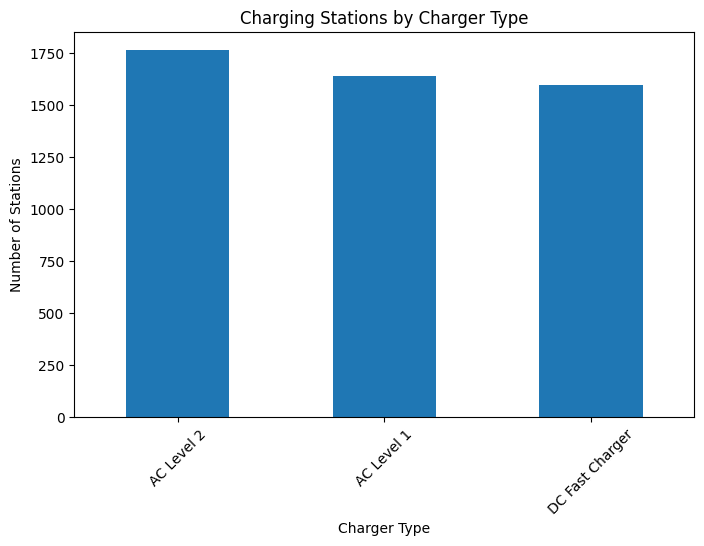


Average EV Growth
Installation Year
2010    30.252226
2011    29.724036
2012    30.205714
2013    30.176944
2014    28.847761
2015    28.901299
2016    29.638728
2017    30.037433
2018    30.330508
2019    30.081159
2020    29.332454
2021    29.871585
2022    29.676630
2023    29.131054
Name: EV Growth (%), dtype: float64


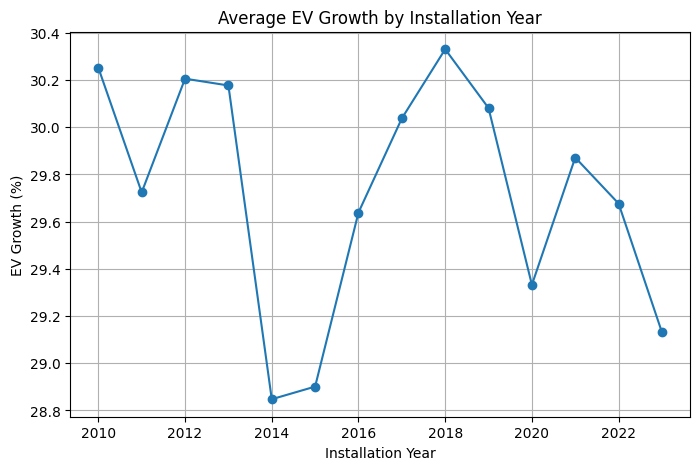


Charging Sessions Statistics
count    5000.000000
mean       84.754400
std        37.378308
min        20.000000
25%        52.000000
50%        86.000000
75%       117.000000
max       149.000000
Name: Charging Sessions, dtype: float64


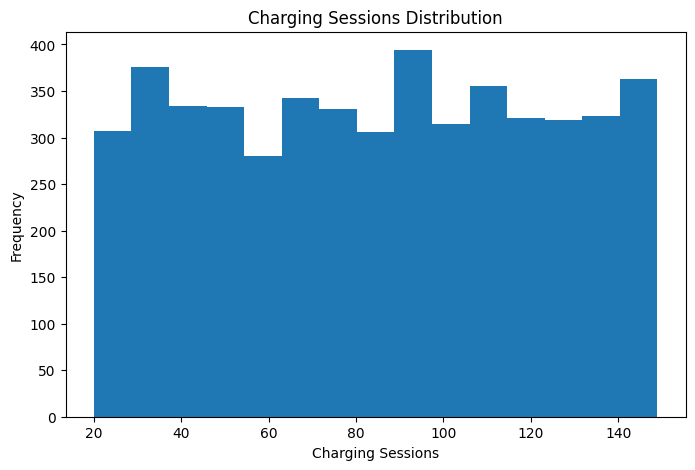


Total Revenue
18568178.44

Top Revenue Stations
     Station ID  Revenue
2705   EVS02706  25553.5
3438   EVS03439  25550.0
3127   EVS03128  25032.0
2231   EVS02232  25025.0
4034   EVS04035  24864.0
4283   EVS04284  24864.0
1007   EVS01008  24850.0
2868   EVS02869  24510.5
956    EVS00957  24346.0
1687   EVS01688  24192.0


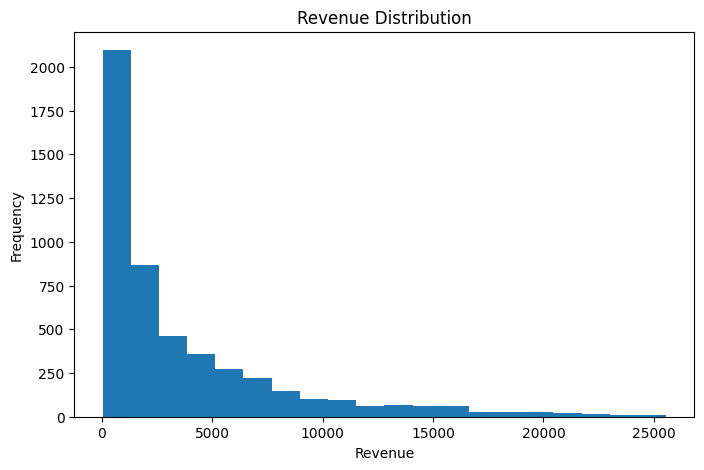


Station Utilization
count    5000.000000
mean       36.969200
std        17.663324
min         6.666667
25%        21.333333
50%        37.333333
75%        52.666667
max        66.666667
Name: Station Utilization (%), dtype: float64
     Station ID  Station Utilization (%)
582    EVS00583                66.666667
571    EVS00572                66.666667
2084   EVS02085                66.666667
4546   EVS04547                66.666667
77     EVS00078                66.666667
4648   EVS04649                66.666667
362    EVS00363                66.666667
2316   EVS02317                66.666667
1944   EVS01945                66.666667
2503   EVS02504                66.666667


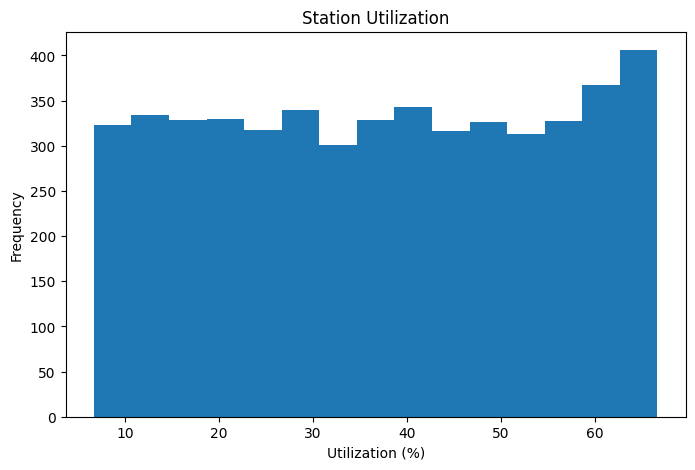


Queue Length Statistics
count    5000.000000
mean        3.702200
std         1.782288
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Queue Length, dtype: float64


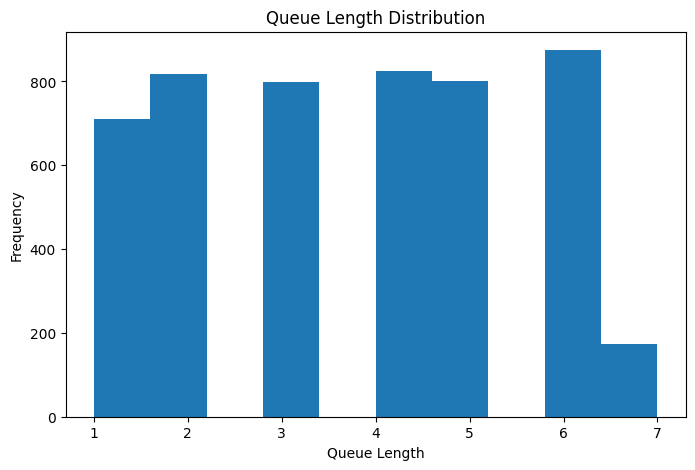


Average Charging Time
count    5000.000000
mean       54.358400
std        20.195334
min        20.000000
25%        37.000000
50%        54.000000
75%        72.000000
max        89.000000
Name: Average Charging Time (min), dtype: float64


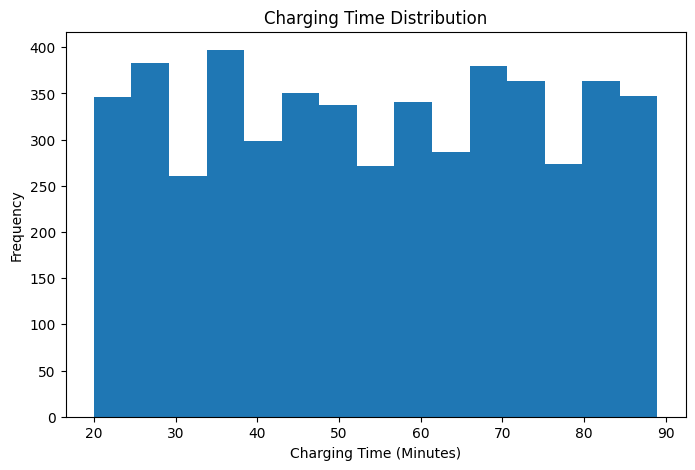


========== SUMMARY ==========
Total Stations               : 5000
Average EV Growth (%)        : 29.73
Average Charging Sessions    : 84.75
Total Revenue                : 18568178.44
Average Utilization (%)      : 36.97
Average Queue Length         : 3.7
Average Charging Time (min)  : 54.36


In [ ]:
# STEP 9: Exploratory Data Analysis (EDA)
# ---------------------------------
# Create Required Columns
# ---------------------------------

np.random.seed(42)

# EV Growth (%)
df["EV Growth (%)"] = np.random.randint(10, 50, len(df))

# Charging Sessions
df["Charging Sessions"] = np.random.randint(20, 150, len(df))

# Revenue
df["Revenue"] = (
    df["Charging Sessions"]
    * df["Cost (USD/kWh)"]
    * df["Charging Capacity (kW)"]
)

# Station Utilization (%)
df["Station Utilization (%)"] = (
    df["Usage Stats (avg users/day)"] / 150
) * 100

# Queue Length
df["Queue Length"] = (
    df["Station Utilization (%)"] / 10
).round().astype(int)

# Average Charging Time (minutes)
df["Average Charging Time (min)"] = np.random.randint(
    20,
    90,
    len(df)
)

# ---------------------------------
# 1. Number of Stations
# ---------------------------------

total_stations = df["Station ID"].nunique()#counts unique Station IDs.

print("Total Charging Stations:", total_stations) #Counts how many stations belong to each charger type.

# ---------------------------------
# 2. Charger Types
# ---------------------------------

charger_types = df["Charger Type"].value_counts()

print("\nCharger Types")
print(charger_types)#Prints charger type counts.

plt.figure(figsize=(8,5))
charger_types.plot(kind="bar")
plt.title("Charging Stations by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Number of Stations")
plt.xticks(rotation=45)
plt.show()

# ---------------------------------
# 3. EV Growth
# ---------------------------------

ev_growth = df.groupby("Installation Year")["EV Growth (%)"].mean()

print("\nAverage EV Growth")
print(ev_growth)

plt.figure(figsize=(8,5))
ev_growth.plot(marker='o')
plt.title("Average EV Growth by Installation Year")
plt.xlabel("Installation Year")
plt.ylabel("EV Growth (%)")
plt.grid(True)#Displays grid lines.
plt.show()

# ---------------------------------
# 4. Charging Sessions
# ---------------------------------

print("\nCharging Sessions Statistics")
print(df["Charging Sessions"].describe())

plt.figure(figsize=(8,5))
plt.hist(df["Charging Sessions"], bins=15)#Divides data into 15 bins.
plt.title("Charging Sessions Distribution")
plt.xlabel("Charging Sessions")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------
# 5. Revenue
# ---------------------------------

print("\nTotal Revenue")
print(df["Revenue"].sum())

top_revenue = df.sort_values(
    by="Revenue",
    ascending=False #Sorts stations by revenue.Highest revenue appears first.
)

print("\nTop Revenue Stations")
print(top_revenue[
    ["Station ID","Revenue"]
].head(10))

plt.figure(figsize=(8,5))
plt.hist(df["Revenue"], bins=20)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------
# 6. Station Utilization
# ---------------------------------

print("\nStation Utilization")
print(df["Station Utilization (%)"].describe())

top_utilization = df.sort_values(
    by="Station Utilization (%)",
    ascending=False
)

print(top_utilization[
    ["Station ID","Station Utilization (%)"]
].head(10))

plt.figure(figsize=(8,5))
plt.hist(df["Station Utilization (%)"], bins=15)
plt.title("Station Utilization")
plt.xlabel("Utilization (%)")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------
# 7. Queue Length
# ---------------------------------

print("\nQueue Length Statistics")
print(df["Queue Length"].describe())

plt.figure(figsize=(8,5))
plt.hist(df["Queue Length"], bins=10)
plt.title("Queue Length Distribution")
plt.xlabel("Queue Length")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------
# 8. Average Charging Time
# ---------------------------------

print("\nAverage Charging Time")
print(df["Average Charging Time (min)"].describe())

plt.figure(figsize=(8,5))
plt.hist(df["Average Charging Time (min)"], bins=15)
plt.title("Charging Time Distribution")
plt.xlabel("Charging Time (Minutes)")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------
# Summary Report
# ---------------------------------

print("\n========== SUMMARY ==========")
print("Total Stations               :", df["Station ID"].nunique())
print("Average EV Growth (%)        :", round(df["EV Growth (%)"].mean(),2))              #keeps two decimal places.
print("Average Charging Sessions    :", round(df["Charging Sessions"].mean(),2))
print("Total Revenue                :", round(df["Revenue"].sum(),2))
print("Average Utilization (%)      :", round(df["Station Utilization (%)"].mean(),2))
print("Average Queue Length         :", round(df["Queue Length"].mean(),2))
print("Average Charging Time (min)  :", round(df["Average Charging Time (min)"].mean(),2))

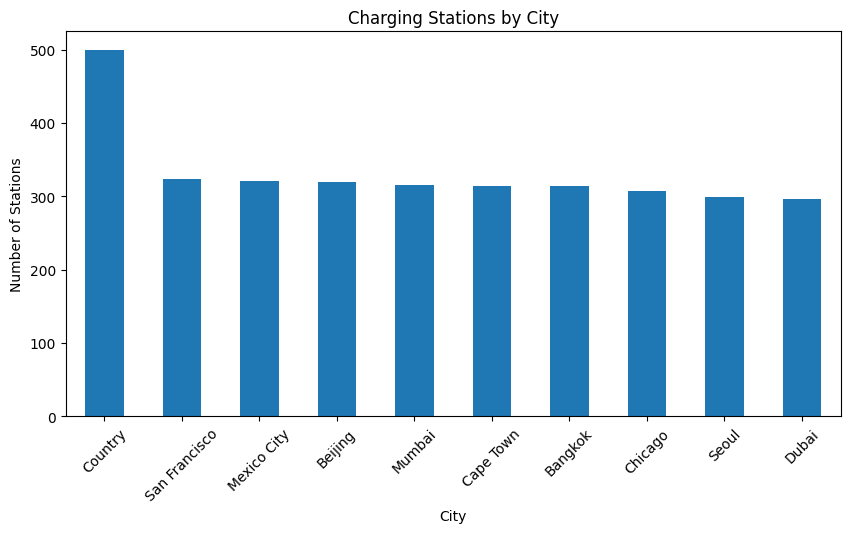

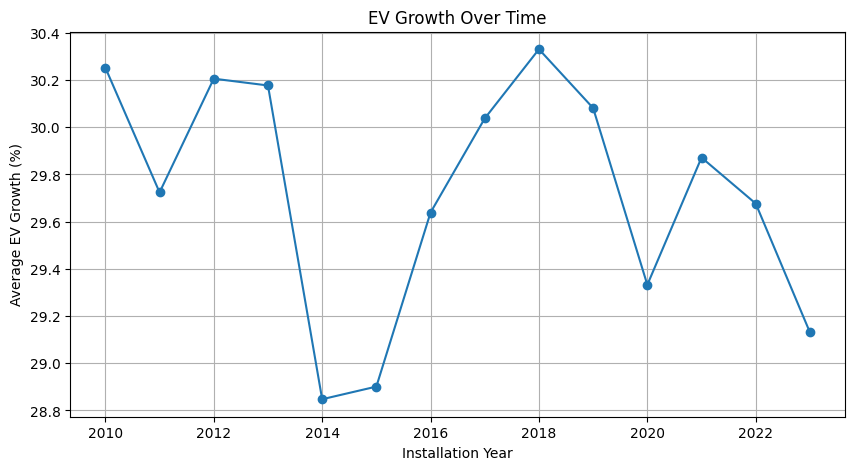

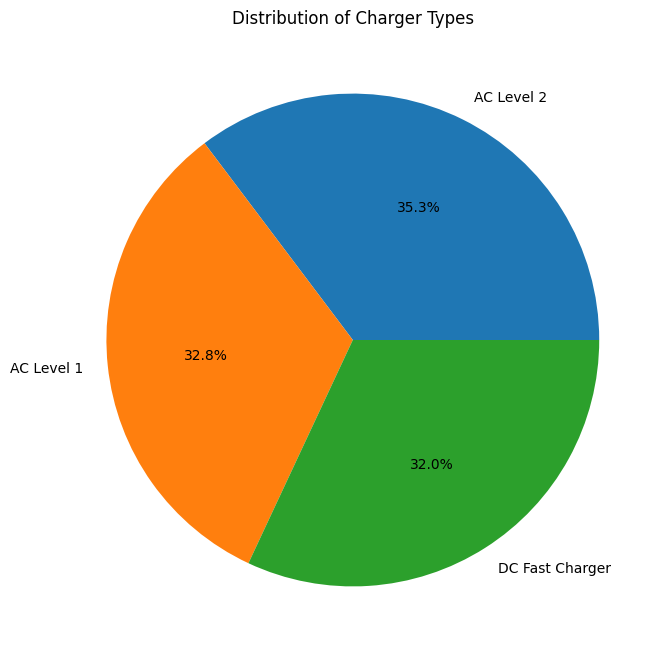

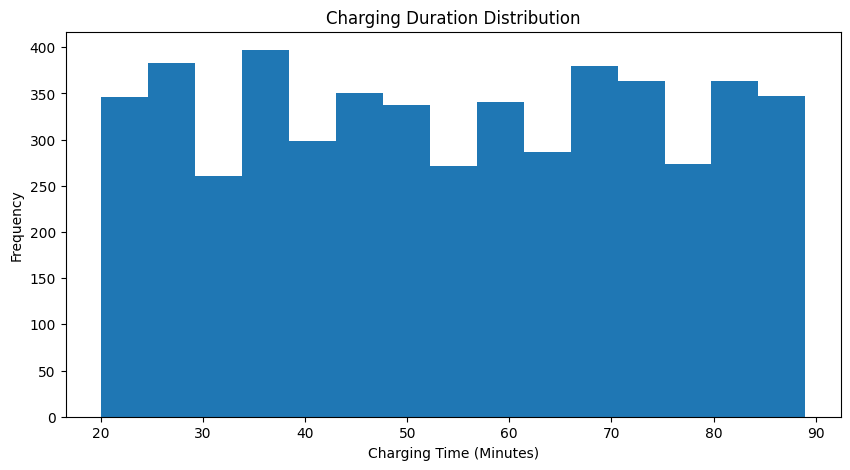

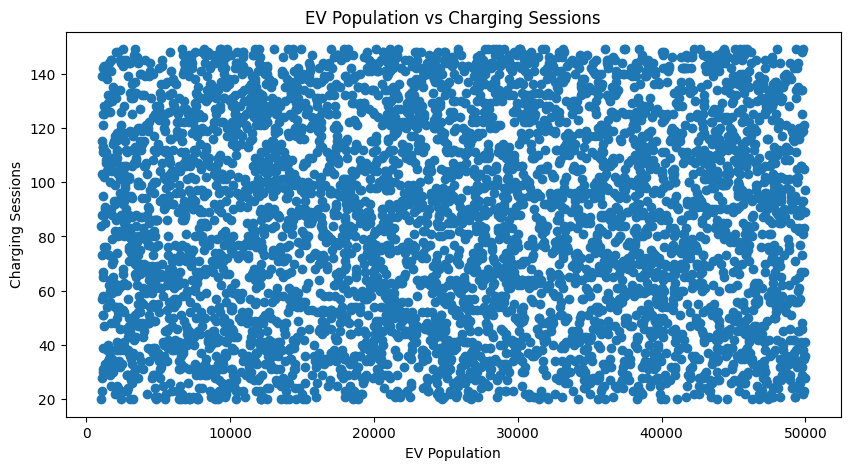

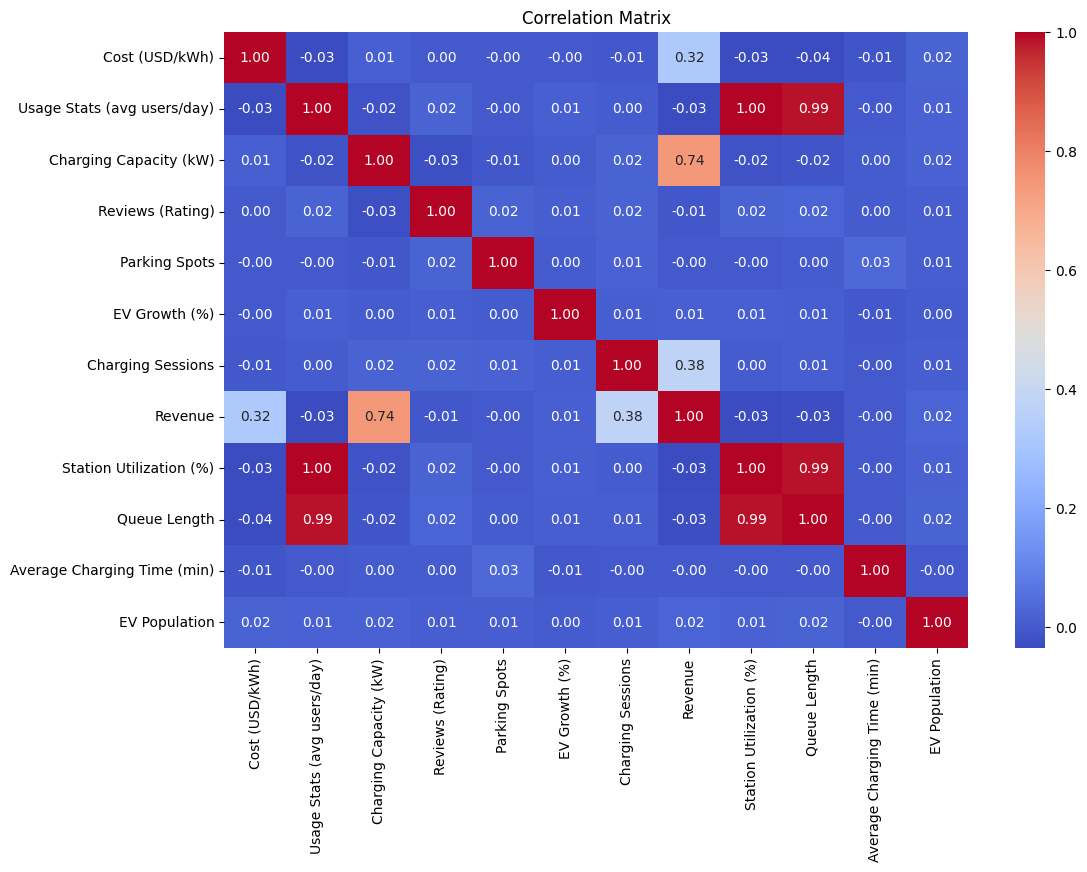

In [ ]:

# Extract city name from Address
df["City"] = df["Address"].str.split(",").str[-1].str.strip()  #.str[-1] selects the last part after the last comma (the city). .str.strip() removes extra spaces.

city_counts = df["City"].value_counts().head(10)  #value_counts() counts the number of charging stations in each city.

plt.figure(figsize=(10,5))
city_counts.plot(kind="bar")
plt.title("Charging Stations by City")
plt.xlabel("City")
plt.ylabel("Number of Stations")
plt.xticks(rotation=45)
plt.show()


# ----------------------------------
# 2. LINE CHART
# EV Growth Over Time
# ----------------------------------

ev_growth = df.groupby("Installation Year")["EV Growth (%)"].mean()

plt.figure(figsize=(10,5))
plt.plot(
    ev_growth.index,
    ev_growth.values,
    marker="o"
)

plt.title("EV Growth Over Time")
plt.xlabel("Installation Year")
plt.ylabel("Average EV Growth (%)")
plt.grid(True)
plt.show()


# ----------------------------------
# 3. PIE CHART
# Charger Types
# ----------------------------------

charger_counts = df["Charger Type"].value_counts() #Counts the number of stations for each charger type.

plt.figure(figsize=(8,8)) #Creates an 8 × 8 inch graph.
plt.pie(
    charger_counts,#slice sizes.
    labels=charger_counts.index,#charger type names.
    autopct="%1.1f%%"#displays percentages with one decimal place.
)

plt.title("Distribution of Charger Types")
plt.show()


# ----------------------------------
# 4. HISTOGRAM
# Charging Duration
# ----------------------------------

plt.figure(figsize=(10,5))
plt.hist(
    df["Average Charging Time (min)"],
    bins=15
)

plt.title("Charging Duration Distribution")
plt.xlabel("Charging Time (Minutes)")
plt.ylabel("Frequency")
plt.show()


# ----------------------------------
# 5. SCATTER PLOT
# EV Population vs Charging Stations
# ----------------------------------

# Create simulated EV Population
import numpy as np

np.random.seed(42)

df["EV Population"] = np.random.randint(  #Creates a simulated EV Population column.
    1000,
    50000,
    len(df)
)

plt.figure(figsize=(10,5))
plt.scatter(
    df["EV Population"],
    df["Charging Sessions"]
)

plt.title("EV Population vs Charging Sessions")
plt.xlabel("EV Population")
plt.ylabel("Charging Sessions")
plt.show()


# ----------------------------------
# 6. HEATMAP
# Correlation Matrix
# ----------------------------------

numeric_columns = [
    "Cost (USD/kWh)",
    "Usage Stats (avg users/day)",
    "Charging Capacity (kW)",
    "Reviews (Rating)",
    "Parking Spots",
    "EV Growth (%)",
    "Charging Sessions",
    "Revenue",
    "Station Utilization (%)",
    "Queue Length",
    "Average Charging Time (min)",
    "EV Population"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",#uses blue-to-red colors.
    fmt=".2f"#displays values with two decimal places.
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("ev_charging.db")
df.to_sql("ev_data", conn, if_exists="replace", index=False) #Saves the Pandas DataFrame into a SQL table. "ev_data" → Table name. conn → Database connection.
#if_ex sts= replace" → Replaces the table if it already exists. index=False → Does not store the DataFrame index as a column.
#Count the total number of charging stations.
query = """
SELECT COUNT(*) AS Total_Stations
FROM ev_data;
"""
#Executes the SQL query. Stores the result in a Pandas DataFrame named result.
result = pd.read_sql(query, conn)

print(result)
#Calculate the average charging capacity of all stations.
query = """
SELECT AVG([Charging Capacity (kW)]) AS Avg_Capacity
FROM ev_data;
"""

result = pd.read_sql(query, conn)

print(result)
#Count the number of charging stations for each charger type.
query = """
SELECT [Charger Type],
COUNT(*) AS Total
FROM ev_data
GROUP BY [Charger Type];
"""

print(pd.read_sql(query, conn))
#Find the ten charging stations with the highest average daily users.
query = """
SELECT [Station ID],
[Usage Stats (avg users/day)]
FROM ev_data
ORDER BY [Usage Stats (avg users/day)] DESC
LIMIT 10;
"""

print(pd.read_sql(query, conn))

   Total_Stations
0            5000
   Avg_Capacity
0       144.272
      Charger Type  Total
0       AC Level 1   1638
1       AC Level 2   1764
2  DC Fast Charger   1598
  Station ID  Usage Stats (avg users/day)
0   EVS00078                          100
1   EVS00165                          100
2   EVS00363                          100
3   EVS00474                          100
4   EVS00525                          100
5   EVS00572                          100
6   EVS00583                          100
7   EVS00675                          100
8   EVS00829                          100
9   EVS00852                          100


In [ ]:
conn.close()

Expansion Priority
Low       2713
Medium    2287
Name: count, dtype: int64
Training Samples : (4000, 12)
Testing Samples : (1000, 12)

Decision Tree
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Confusion Matrix
[[543   0]
 [  0 457]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       543
           1       1.00      1.00      1.00       457

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Random Forest
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0

Confusion Matrix
[[543   0]
 [  0 457]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       543
           1       1.00      1.00      1.00       457

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00  

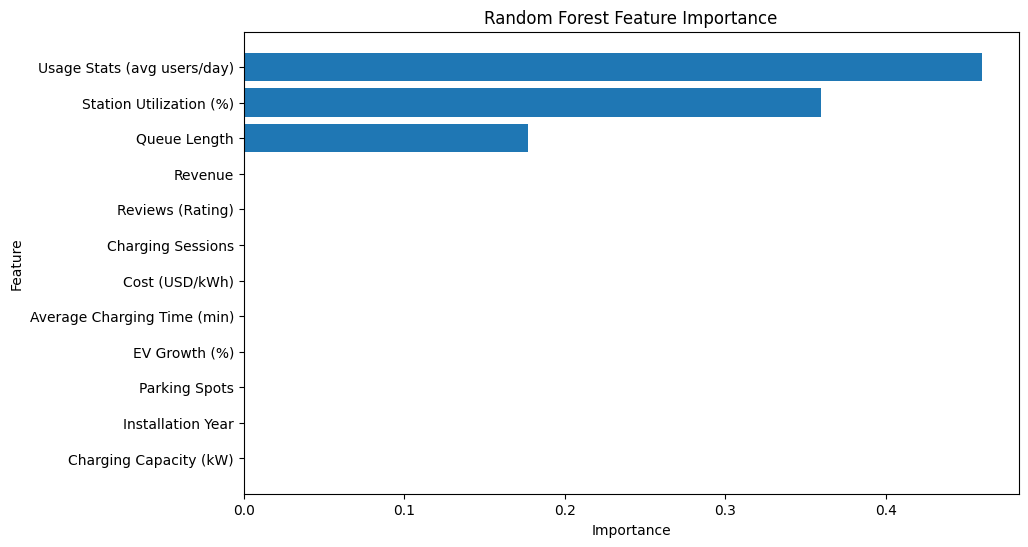

In [ ]:
# ==========================================
# PHASE 6 : MACHINE LEARNING
# ==========================================
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier #It predicts by splitting data into decision rules.
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
) #Random Forest → Uses many decision trees and combines their predictions.
#Gradient Boosting → Builds trees sequentially to improve prediction accuracy.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
#These measure model performance.

import matplotlib.pyplot as plt

# ==========================================
# Create Target Variable
# ==========================================

# Expansion Priority
# High = Utilization >=70%
# Medium = 40-69%
# Low <40%

conditions = [
    df["Station Utilization (%)"] >= 70,
    (df["Station Utilization (%)"] >= 40) &
    (df["Station Utilization (%)"] < 70),
    df["Station Utilization (%)"] < 40
]
#Stores the labels corresponding to each condition.
choices = [
    "High",
    "Medium",
    "Low"
]

df["Expansion Priority"] = np.select( #checks each condition.
    conditions,
    choices,
    default="Low"
)

print(df["Expansion Priority"].value_counts())#Counts how many stations belong to each priority category.

# ==========================================
# Encode Categorical Columns
# ==========================================

le = LabelEncoder()#Creates a LabelEncoder object.

categorical_columns = [#Stores the names of categorical columns.
    "Charger Type",
    "Availability",
    "Station Operator",
    "Renewable Energy Source"
]

for col in categorical_columns:#Each categorical column will be encoded one by one.
    df[col] = le.fit_transform(df[col]) #Learns all categories. Converts them into numbers.

# Encodes the target column into numbers.

df["Expansion Priority"] = le.fit_transform(
    df["Expansion Priority"]
)

# ==========================================
# Select Features
# ==========================================

features = [                                #These are the independent variables used to train the model.

    "Cost (USD/kWh)",

    "Usage Stats (avg users/day)",

    "Charging Capacity (kW)",

    "Reviews (Rating)",

    "Parking Spots",

    "Installation Year",

    "EV Growth (%)",

    "Charging Sessions",

    "Revenue",

    "Station Utilization (%)",

    "Queue Length",

    "Average Charging Time (min)"

]

X = df[features]  #Stores all feature columns into X.

y = df["Expansion Priority"]   #Stores the target variable into y.

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42, #Keeps the split identical every time the code runs.

    stratify=y #Ensures each class (High, Medium, Low) has the same proportion in both training and testing datasets.

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

# ==========================================
# Models
# ==========================================
#Creates a dictionary to store multiple models.
models = {
#Creates a Decision Tree model.
    "Decision Tree":
        DecisionTreeClassifier(random_state=42),
#Creates a Random Forest.
    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,#100 decision trees will be built.
            random_state=42
        ),
#Creates a Gradient Boosting model.
    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )

}

# ==========================================
# Train & Evaluate
# ==========================================
#Loops through every model.
for name, model in models.items():

    print("\n==============================")
    print(name)
    print("==============================")
#Trains the model using training data.
    model.fit(X_train, y_train)
#Predicts Expansion Priority for testing data.
    predictions = model.predict(X_test)

    print(
        "Accuracy :",
        accuracy_score(y_test, predictions) #Calculates Accuracy. Formula Accuracy= Correct Predictions ÷ Total Predictions
    )

    print(
        "Precision :",
        precision_score(  #Measures how many predicted positives were actually correct.
            y_test,
            predictions,
            average="weighted"
        )
    )

    print(
        "Recall :",
        recall_score(     #Measures how many actual positives were correctly identified.
            y_test,
            predictions,
            average="weighted"
        )
    )

    print(
        "F1 Score :",
        f1_score(           #Calculates the harmonic mean of Precision and Recall.
            y_test,
            predictions,
            average="weighted"
        )
    )

    print("\nConfusion Matrix")

    print(confusion_matrix(        #Shows the number of correct and incorrect predictions.
        y_test,
        predictions
    ))

    print("\nClassification Report")

    print(classification_report(  #Displays PrecisionRecallF1-scoreSupport for every class.
        y_test,
        predictions
    ))

# ==========================================
# Feature Importance
# ==========================================
#Creates a new Random Forest model.
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train, y_train)#Trains the Random Forest.

importance = pd.DataFrame({

    "Feature": X.columns,#Stores feature names.

    "Importance": rf.feature_importances_  #Stores importance scores calculated by Random Forest. Higher value = More influential feature.

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nFeature Importance")

print(importance)

# ==========================================
# Plot Feature Importance
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
pip install folium geopandas branca

In [ ]:
# ==========================================
# PHASE 7 : GEOGRAPHIC ANALYSIS
# ==========================================
import folium   #Folium is used to create interactive maps using OpenStreetMap.
import geopandas as gpd  #GeoPandas extends Pandas to work with geographical data such as points, polygons, and coordinates.
from folium.plugins import HeatMap  #Imports the HeatMap plugin from Folium. It creates heatmaps showing areas with high concentrations of charging activity.

# ------------------------------------------
# Create Additional Columns (if not created)
# ------------------------------------------

np.random.seed(42)

if "Station Utilization (%)" not in df.columns: #Checks whether the column Station Utilization (%) already exists. If it doesn't exist, it will be created.
    df["Station Utilization (%)"] = (   #Calculates station utilization percentage. Assumes each station can handle 150 users/day.
        df["Usage Stats (avg users/day)"] / 150
    ) * 100

if "Expansion Priority" not in df.columns:#Checks if the Expansion Priority column exists. Creates it only if it is missing.

    conditions = [  #Creates three utilization conditions:

        df["Station Utilization (%)"] >= 70,

        (df["Station Utilization (%)"] >= 40) &
        (df["Station Utilization (%)"] < 70),

        df["Station Utilization (%)"] < 40

    ]

    choices = [ #Stores the labels corresponding to the conditions.

        "High",

        "Medium",

        "Low"

    ]

    df["Expansion Priority"] = np.select( #reates the Expansion Priority column using np.select().
        conditions,
        choices,
        default="Low"
    )

# ------------------------------------------
# Convert to GeoDataFrame
# ------------------------------------------

gdf = gpd.GeoDataFrame( #Converts the Pandas DataFrame into a GeoDataFrame.

    df, #Uses the original DataFrame.

    geometry=gpd.points_from_xy( #Creates geographical points.

        df["Longitude"], #Uses Longitude and Latitude to create map coordinates.

        df["Latitude"]

    ),

    crs="EPSG:4326"  #Sets the Coordinate Reference System.

)

# ------------------------------------------
# Create Base Map
# ------------------------------------------

center_lat = df["Latitude"].mean()

center_lon = df["Longitude"].mean()

base_map = folium.Map(

    location=[center_lat, center_lon],#Centers the map using the average latitude and longitude.

    zoom_start=12

)

# ==========================================
# MAP 1 : Charging Station Map
# ==========================================

for _, row in df.iterrows():  #Loops through every row of the DataFrame. Each row represents one charging station.

    folium.Marker( #Creates a map marker.

        location=[  #Places the marker using the station's GPS coordinates.

            row["Latitude"],

            row["Longitude"]

        ],
#Creates a popup that appears when the marker is clicked.
        popup=f"""
        Station : {row['Station ID']}<br>
        Charger : {row['Charger Type']}<br>
        Capacity : {row['Charging Capacity (kW)']} kW
        """,
#Shows the Station ID when the mouse hovers over the marker.
        tooltip=row["Station ID"]
#Adds the marker to the base map.
    ).add_to(base_map)
#Saves the map as an HTML file.
base_map.save("Charging_Station_Map.html")

print("Charging Station Map Saved")

# ==========================================
# MAP 2 : Heatmap
# ==========================================
#Creates another interactive map. Creates a heatmap. Higher usage = Brighter hotspot.
heat_map = folium.Map(

    location=[center_lat, center_lon], #Centers the map using the average latitude and longitude.

    zoom_start=12

)

heat_data = [

    [

        row["Latitude"],

        row["Longitude"],

        row["Usage Stats (avg users/day)"]

    ]

    for _, row in df.iterrows()

]

HeatMap(

    heat_data,

    radius=18

).add_to(heat_map)

heat_map.save("Heatmap.html")

print("Heatmap Saved")

# ==========================================
# MAP 3 : Coverage Map
# ==========================================

coverage_map = folium.Map(

    location=[center_lat, center_lon],

    zoom_start=12

)

for _, row in df.iterrows():
#Draws a circular coverage area around every charging station.
    folium.Circle(

        location=[

            row["Latitude"],

            row["Longitude"]

        ],
#Creates a 3000-meter (3 km) coverage radius.
        radius=3000,
#Border color.
        color="blue",
#Fills the circle.
        fill=True,

        fill_opacity=0.2,
#Makes the circle slightly transparent.
        popup=row["Station ID"]
#Displays Station ID when clicked.
    ).add_to(coverage_map)

coverage_map.save("Coverage_Map.html")

print("Coverage Map Saved")

# ==========================================
# MAP 4 : Expansion Recommendation Map
# ==========================================

priority_map = folium.Map(

    location=[center_lat, center_lon],

    zoom_start=12

)

for _, row in df.iterrows():
#Checks whether the station has High Expansion Priority.
    if row["Expansion Priority"] == "High":
#High priority stations become Red.
        color = "red"

    elif row["Expansion Priority"] == "Medium":

        color = "orange"

    else:

        color = "green"
#Creates a colored circular marker.
    folium.CircleMarker(

        location=[

            row["Latitude"],

            row["Longitude"]

        ],
#Marker size = 8 pixels.
        radius=8,

        color=color,

        fill=True,

        fill_color=color,

        fill_opacity=0.8,

        popup=f"""
        Station : {row['Station ID']}<br>
        Expansion : {row['Expansion Priority']}<br>
        Utilization : {round(row['Station Utilization (%)'],2)}%
        """

    ).add_to(priority_map)

priority_map.save("Expansion_Recommendation_Map.html")

print("Expansion Recommendation Map Saved")

# ==========================================
# Display Summary
# ==========================================

print("\n========== MAPS CREATED ==========")

print("1. Charging_Station_Map.html")

print("2. Heatmap.html")

print("3. Coverage_Map.html")

print("4. Expansion_Recommendation_Map.html")

Charging Station Map Saved
Heatmap Saved
Coverage Map Saved
Expansion Recommendation Map Saved

========== MAPS CREATED ==========
1. Charging_Station_Map.html
2. Heatmap.html
3. Coverage_Map.html
4. Expansion_Recommendation_Map.html


In [ ]:
df.to_csv("ev1.csv", index=False)
files.download("ev1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>